# Zheng et al. (2017) – Massively parallel digital transcriptional profiling of single cells

The original paper can be found here: https://www.nature.com/articles/ncomms14049

__Abstract__: Characterizing the transcriptome of individual cells is fundamental to understanding complex biological systems. We describe a droplet-based system that enables 3′ mRNA counting of tens of thousands of single cells per sample. Cell encapsulation, of up to 8 samples at a time, takes place in ∼6 min, with ∼50% cell capture efficiency. To demonstrate the system’s technical performance, we collected transcriptome data from ∼250k single cells across 29 samples. We validated the sensitivity of the system and its ability to detect rare populations using cell lines and synthetic RNAs. We profiled 68k peripheral blood mononuclear cells to demonstrate the system’s ability to characterize large immune populations. Finally, we used sequence variation in the transcriptome data to determine host and donor chimerism at single-cell resolution from bone marrow mononuclear cells isolated from transplant patients.

A 10x Chromium immune benchmark: ~14k human PBMCs assembled from FACS-sorted populations (CD14⁺ monocytes, B cells, NK, CD4/8 T, &c.). The data set is UMI-based droplet data, and can be used as a multi-class ground truth because the cells come from purified sorts.

From scMINER: The data of this study was originally collected from SRP073767 and used as a ground truth to benchmark scMINER and other tools. In this study, the authors performed single cell RNA-Seq experiment on 10 sorted populations of Peripheral Blood Mononuclear Cells (PBMCs): CD14+ Monocyte, CD19+ B, CD34+, CD4+ T Helper2, CD4+/CD25 T Reg, CD4+/CD45RA+/CD25- Naive T, CD4+/CD45RO+ Memory, CD56+ NK, CD8+ Cytotoxic T, CD8+/CD45RA+ Naive Cytotoxic. The library was prepared with GemCode Single-Cell 3′ Gel Bead and Library Kit (10x Genomics) and sequenced on NextSeq 500 (Illumina). For benchmark purpuses, we removed 3 cell populations, CD34+ cells, CD4+ helper T cells, and total CD8+ cytotoxic cells, from the dataset because of either low sorting purity or a significant overlap with other immune cells based on the sorting strategy, and created a new dataset with seven known cell types and 14k cells in total. Zheng, Grace XY, et al. "Massively parallel digital transcriptional profiling of single cells." Nature communications 8.1 (2017): 14049.

## 0. Imports & Set-Up:

In [1]:
import sys; sys.path.insert(0, "..")

import multiprocessing
import os, random

from pathlib import Path

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad

from carve import CARVE

In [2]:
SUBSAMPLE = False
subsample_size = 2800

In [3]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [4]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [8]:
from benchmarking_code.benchmarking_utils import gamma_quantile_approx
from benchmarking_code.case_study_plotting import plot_dim_red, calculate_baseline_aris_and_plot, baseline_metrics_over_k, alluvial_compare

---

## 1. Pre-Process the Data

In [9]:
DATA_DIR = "../../data/Zheng PBMC14K"
FP_EXPR = f"{DATA_DIR}/Filtered_DownSampled_SortedPBMC_data.csv"
FP_ANN  = f"{DATA_DIR}/GRCh37.87.geneAnnotation.txt"
FP_LAB  = f"{DATA_DIR}/PBMC_20k_true_label.txt"

Read in annotation data:

In [10]:
expr = pd.read_csv(FP_EXPR, index_col=0)

# consider orientation: if rows >> cols and looks like genes x cells, transpose to cells x genes
if expr.shape[0] < expr.shape[1]:
    print('already cells x genes')
    Xdf = expr
else:
    print('genes x cells -> transpose to cells x genes')
    Xdf = expr.T

already cells x genes


Ensure numeric:

In [11]:
Xdf = Xdf.apply(pd.to_numeric, errors="coerce")
Xdf = Xdf.loc[:, Xdf.notna().any(axis=0)].fillna(0.0)

print("cells x genes:", Xdf.shape)

cells x genes: (20000, 21952)


Read true labels (txt; tab-separated with columns like ID, label):

In [12]:
lab = pd.read_csv(FP_LAB, sep="\t")
    
# try 
candidates_id = [c for c in lab.columns if c.lower() in {"id", "barcode", "cell", "cell_id"}]
candidates_lb = [c for c in lab.columns if "label" in c.lower() or "type" in c.lower() or "pop" in c.lower()]

if not candidates_id or not candidates_lb:
    print("Label columns:", lab.columns.tolist())
    raise ValueError("Could not infer ID/label columns—inspect printed columns and set manually.")

id_col, lb_col = candidates_id[0], candidates_lb[0]
lab = lab[[id_col, lb_col]].rename(columns={id_col: "cell_id", lb_col: "cell_type"})
lab["cell_id"] = lab["cell_id"].astype(str)
lab["cell_type"] = lab["cell_type"].astype("category")

lab = lab.set_index("cell_id")

Align by intersection of "cell_id":

In [13]:
common = Xdf.index.astype(str).intersection(lab.index)
if len(common) == 0:
    # Sometimes barcodes in matrix have suffixes like "-1"; try stripping
    X_index = Xdf.index.astype(str).str.replace("-1$", "", regex=True)
    Xdf.index = X_index
    common = Xdf.index.intersection(lab.index)

Xdf = Xdf.loc[common]
lab = lab.loc[common]
print("aligned cells:", Xdf.shape[0])

aligned cells: 20000


Gene annotation, add gene symbols for var:

In [14]:
ann = pd.read_csv(FP_ANN, sep="\t")

# try to guess columns
ens_cols = [c for c in ann.columns if "ensembl" in c.lower() or c.lower() in {"gene_id", "ensembl_gene_id"}]
sym_cols = [c for c in ann.columns if "symbol" in c.lower() or c.lower() in {"hgnc_symbol", "gene_name"}]

if ens_cols and sym_cols:
    ens_col, sym_col = ens_cols[0], sym_cols[0]
    ann = ann[[ens_col, sym_col]].dropna()
    ann[ens_col] = ann[ens_col].astype(str)
    ann = ann.drop_duplicates(subset=[ens_col]).set_index(ens_col)
    
    # If Xdf columns are Ensembl IDs, can map; otherwise store names as-is
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))
    
    if var.index.isin(ann.index).any():
        var["gene_symbol"] = ann.reindex(var.index)[sym_col].values
    else:
        # Xdf already uses symbols?
        var = var.rename_axis("gene_symbol").copy()
else:
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))

Build adata object:

In [15]:
# Remove cell populations from lab and Xdf as scMINER
exclude_types = [
    "CD34+",
    "CD4+ T Helper2",
    "CD8+ Cytotoxic T"
]
keep_cells = lab[~lab["cell_type"].isin(exclude_types)].index
Xdf = Xdf.loc[keep_cells]
lab = lab.loc[keep_cells]

adata = ad.AnnData(
    X = Xdf.values.astype(np.float32),  # raw UMI counts
    obs = pd.DataFrame(index=pd.Index(Xdf.index.astype(str), name="barcode")),
    var = var,
)
adata.obs["cell_type"] = lab["cell_type"].astype("category")
adata.layers["counts"] = adata.X.copy()  # preserve raw counts

# name hygiene so .write() works cleanly
adata.obs.columns = adata.obs.columns.astype(str)
adata.var.columns = adata.var.columns.astype(str)
adata.obs_names.name = "barcode"
adata.var_names = adata.var_names.astype(str)
adata.var_names.name = adata.var_names.name or "gene_id"

adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

print(adata)
print(adata.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 14000 × 21952
    obs: 'cell_type'
    layers: 'counts'
cell_type
CD14+ Monocyte                  2000
CD19+ B                         2000
CD4+/CD25 T Reg                 2000
CD4+/CD45RA+/CD25- Naive T      2000
CD4+/CD45RO+ Memory             2000
CD56+ NK                        2000
CD8+/CD45RA+ Naive Cytotoxic    2000
Name: count, dtype: int64


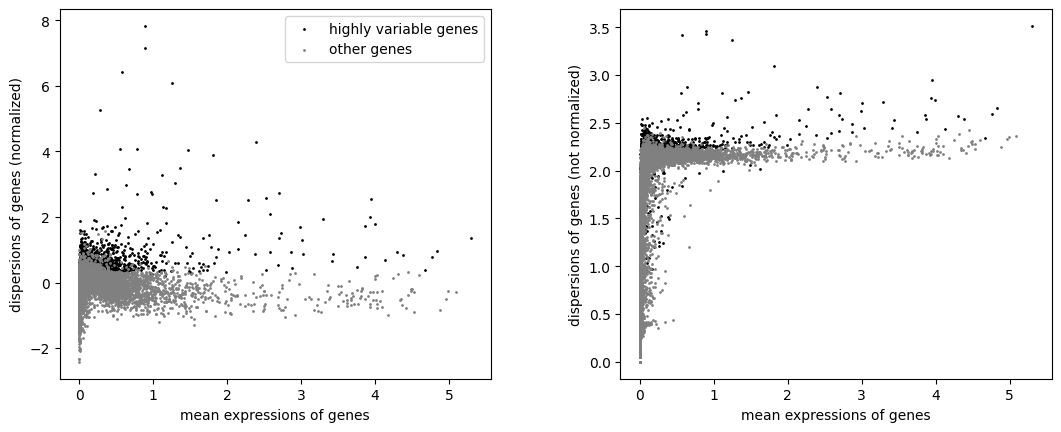

In [16]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="cell_type", flavor='seurat')
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var["highly_variable"]].copy()

---

## 2. Analyse Data

In [17]:
# Extract X (features) and y (labels)
X = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
X = X.to_numpy()

y = lab['cell_type']

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")
print(f"y shape: {y.shape}")
print(f"Number of unique cell types in y: {y.nunique()}")

X shape (cells × genes): 14,000 × 2,000
y shape: (14000,)
Number of unique cell types in y: 7


In [18]:
# Stratified subsampling
if SUBSAMPLE:
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]

    X_sub = X[idx]
    y_sub = y.loc[selected_idx]
    
    X = X_sub
    y = y_sub

    print("X shape:", X.shape)

### 2.1 Plot PCA:

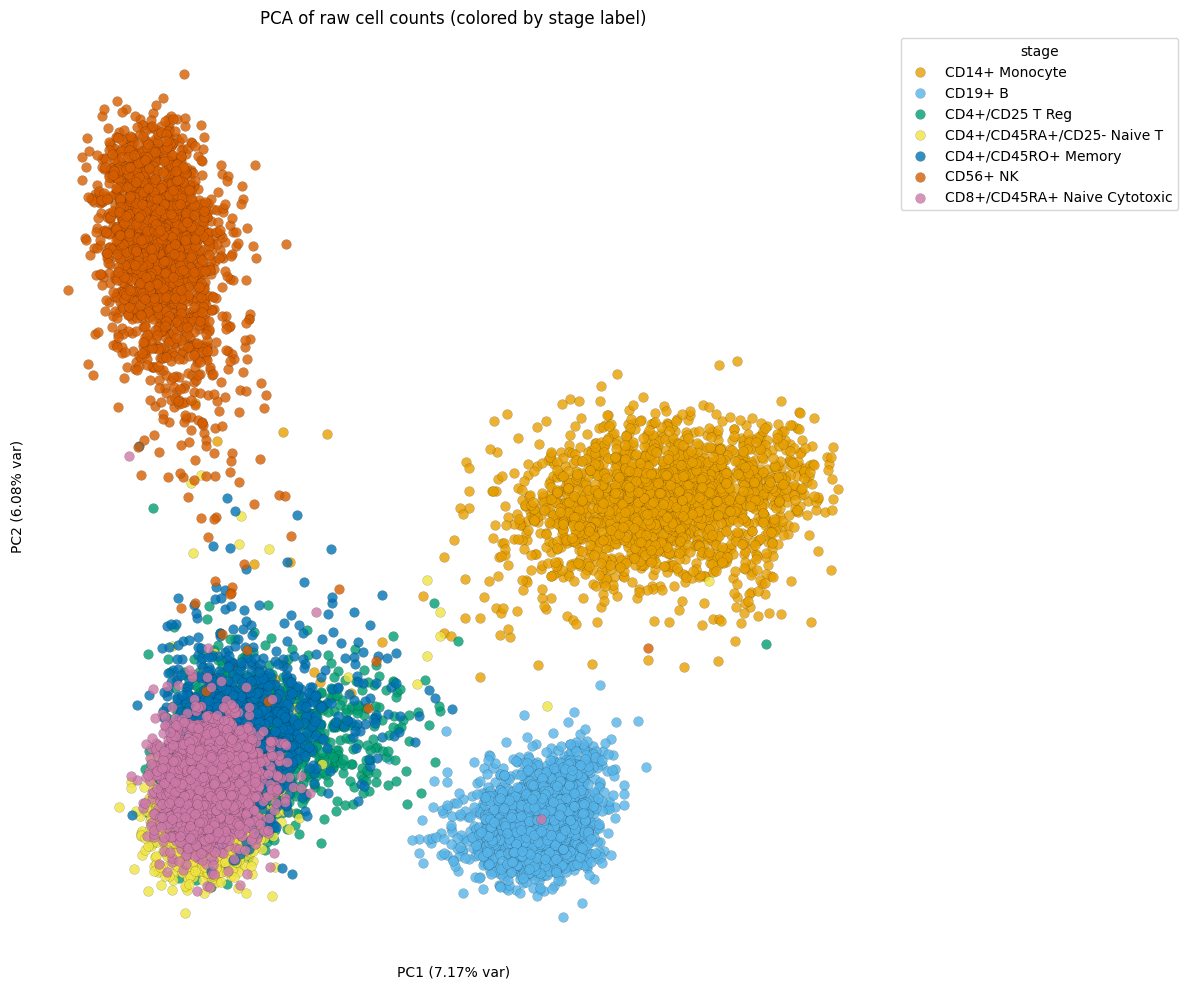

In [19]:
plot_dim_red(X=X, y=y, label_col="cell_type")

### 2.2 Perform Clustering with "Oracle" Number of Clusters:

In [ ]:
calculate_baseline_aris_and_plot(X=X, y=y, random_state=RANDOM_SEED)

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [18]:
K = 12
ks = np.arange(3, K+1)

gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
gamma_01  = gamma_quantile_approx(X, q=0.10, random_state=RANDOM_SEED)
gamma_05  = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

model_grids = [
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]})
]


baseline selections (max metric):
  - Silhouette: k=4, score=0.0704, ari=0.2149   [Spectral (gamma=0.000916)]
  - Gap Statistic: k=12, score=1.7064, ari=0.4585   [Agglomerative (linkage=ward)]
  - DB: k=4, score=0.2597, ari=0.1914   [Agglomerative (linkage=ward)]
  - CH: k=3, score=46.8168, ari=0.1869   [Spectral (gamma=0.000916)]


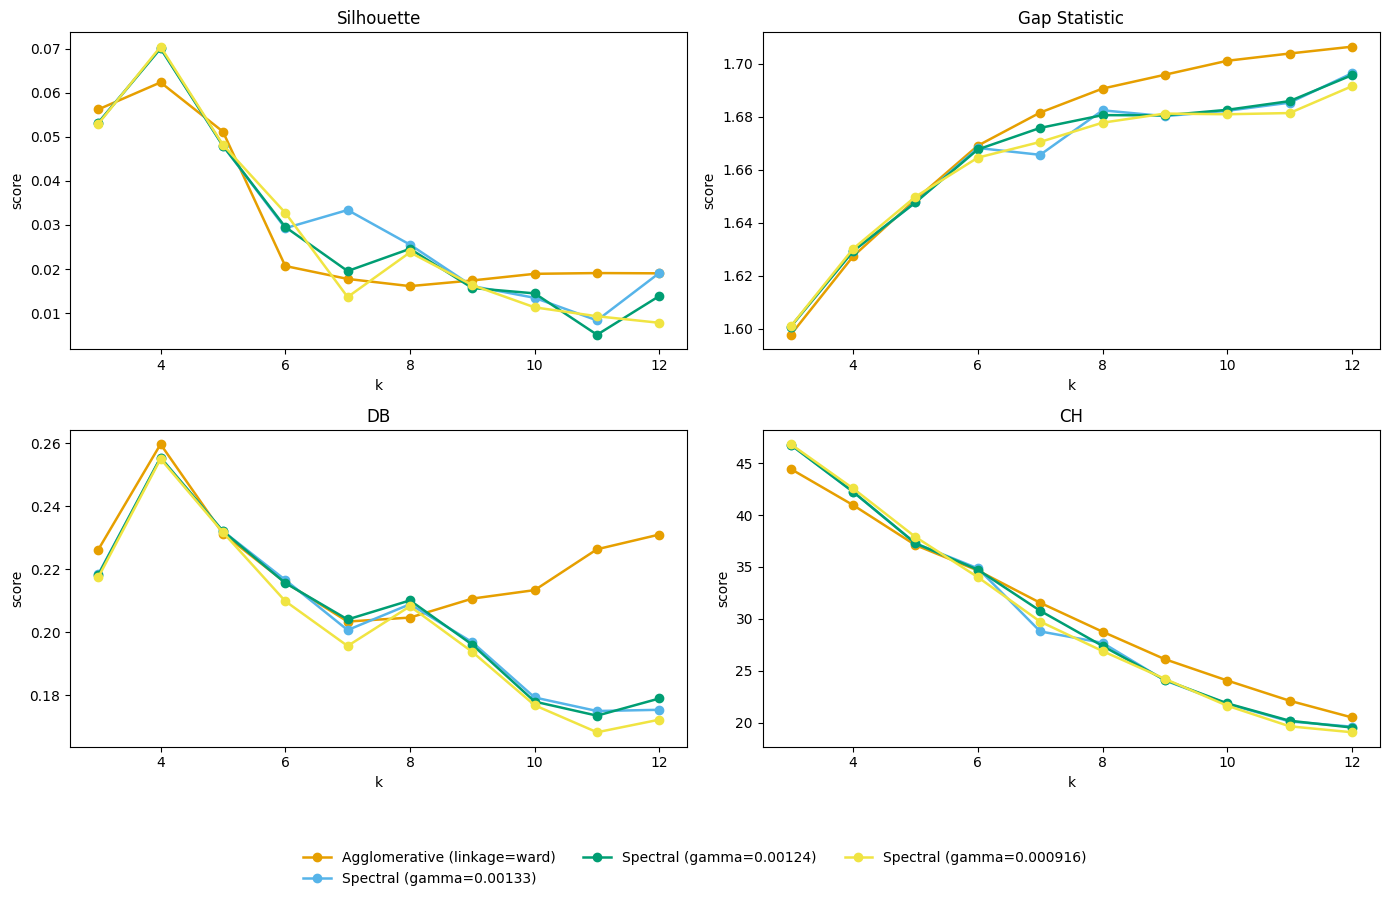

In [19]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,
    model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    random_state=RANDOM_SEED,
    ncols=2,
    figsize=(14, 9),
)

---

## 4. Run CARVE:

In [20]:
carve = CARVE(
    estimator_param_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1000
[CARVE] n_features         : 21952
[CARVE] n_clusters         : 10
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 40
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/40] est=AgglomerativeClustering n_clusters=3 | ARI_stab=0.809±0.015  ARI_gen=0.641±0.019  ARI_avg=0.725±0.013
[CARVE] [2/40] est=AgglomerativeClustering n_clusters=4 | ARI_stab=0.867±0.010  ARI_gen=0.780±0.016  ARI_avg=0.823±0.009
[CARVE] [3/40] est=AgglomerativeClustering n_clusters=5 | ARI_stab=0.706±0.021  ARI_gen=0.612±0.017  ARI_avg=0.659±0.015
[CARVE] [4/40] est=AgglomerativeClustering n_clusters=6 | ARI_stab=0.765±0.017  ARI_gen=0.645±0.015  ARI_avg=0.705±0.012
[CARVE] [5/40] es

CARVE(n_clusters=10, n_resamples=100, subsample_ratio=0.8, estimator_param_grids=[(<class 'sklearn.cluster._agglomerative.AgglomerativeClustering'>, {'n_clusters': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), 'linkage': ['ward']}), (<class 'sklearn.cluster._spectral.SpectralClustering'>, {'n_clusters': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), 'gamma': [0.0013307273745603507, 0.0012382551267417486, 0.0009156385809678725]})], normalization_options=None, dim_reduction_options=None, reference_labels=array([0, 1, 2, 0, 0, 3, 1, 4, 4, 2, 2, 2, 5, 3, 6, 4, 2, 6, 5, 4, 1, 5,
       0, 2, 3, 5, 2, 4, 5, 0, 5, 2, 3, 3, 6, 1, 3, 4, 6, 3, 0, 3, 6, 5,
       1, 3, 0, 5, 4, 0, 3, 2, 0, 3, 1, 3, 2, 6, 3, 0, 1, 4, 1, 3, 0, 0,
       6, 4, 2, 6, 5, 1, 4, 6, 0, 3, 3, 0, 4, 2, 3, 0, 1, 1, 6, 1, 5, 6,
       3, 3, 4, 3, 1, 0, 3, 5, 3, 0, 6, 3, 1, 5, 6, 5, 2, 5, 6, 4, 3, 1,
       3, 1, 2, 2, 0, 3, 0, 4, 2, 5, 5, 3, 3, 2, 5, 4, 1, 5, 0, 1, 2, 2,
       4, 3, 5, 2, 5, 2, 1, 4, 3, 3, 1, 5, 1, 6, 6, 6, 2, 3, 4, 4, 4, 0,
       4, 6, 1, 2, 4, 4, 1, 6, 4, 0, 5, 0, 4, 0, 5, 5, 6, 3, 6, 5, 0, 6,
       1, 5, 1, 0, 5, 2, 0, 4, 4, 1, 6, 4, 5, 6, 3, 3, 2, 4, 0, 4, 5, 5,
       4, 3, 5, 4, 0, 5, 6, 1, 2, 3, 1, 5, 1, 6, 3, 1, 2, 2, 4, 2, 0, 1,
       5, 6, 3, 3, 1, 5, 4, 2, 5, 4, 4, 4, 6, 3, 6, 4, 3, 0, 6, 3, 2, 1,
       1, 1, 2, 0, 0, 2, 5, 5, 5, 6, 4, 2, 2, 1, 4, 1, 2, 2, 1, 5, 3, 3,
       6, 1, 2, 1, 2, 3, 1, 1, 2, 6, 4, 5, 4, 2, 1, 2, 3, 2, 0, 5, 1, 3,
       6, 3, 3, 6, 4, 2, 6, 3, 0, 4, 1, 3, 2, 5, 1, 1, 5, 3, 1, 1, 5, 0,
       4, 3, 3, 0, 4, 6, 6, 3, 5, 6, 5, 4, 0, 3, 1, 5, 6, 3, 0, 1, 2, 5,
       5, 2, 1, 6, 4, 3, 6, 5, 3, 2, 3, 4, 2, 5, 1, 3, 2, 1, 0, 0, 6, 6,
       4, 4, 0, 5, 6, 5, 1, 1, 6, 6, 6, 4, 5, 6, 3, 2, 2, 1, 1, 2, 1, 5,
       1, 1, 3, 6, 6, 6, 6, 1, 5, 0, 1, 6, 4, 4, 2, 6, 1, 1, 0, 0, 4, 2,
       4, 0, 0, 4, 1, 0, 2, 6, 5, 5, 6, 6, 6, 4, 1, 5, 6, 3, 3, 3, 1, 0,
       3, 6, 5, 2, 5, 3, 0, 5, 5, 0, 5, 3, 5, 2, 1, 5, 3, 6, 1, 5, 2, 0,
       5, 4, 2, 4, 0, 3, 5, 5, 2, 4, 0, 3, 5, 3, 1, 2, 1, 6, 3, 4, 6, 0,
       6, 2, 2, 2, 6, 4, 2, 5, 3, 0, 1, 0, 3, 6, 3, 6, 1, 4, 3, 2, 4, 5,
       3, 6, 4, 5, 0, 4, 4, 4, 3, 5, 4, 2, 4, 6, 3, 1, 0, 4, 6, 6, 1, 4,
       6, 1, 0, 3, 2, 3, 3, 2, 0, 4, 0, 6, 4, 2, 1, 0, 5, 2, 5, 5, 3, 6,
       6, 0, 1, 4, 0, 1, 2, 6, 1, 5, 0, 2, 4, 1, 3, 3, 5, 5, 3, 6, 3, 4,
       3, 1, 5, 1, 2, 1, 4, 3, 2, 1, 1, 4, 6, 5, 4, 6, 4, 6, 4, 0, 5, 4,
       6, 0, 2, 1, 0, 3, 4, 2, 3, 4, 0, 5, 4, 6, 0, 3, 3, 6, 6, 6, 1, 6,
       1, 5, 4, 4, 5, 5, 0, 1, 0, 1, 0, 4, 5, 0, 2, 6, 1, 3, 0, 2, 2, 1,
       5, 6, 0, 6, 5, 5, 6, 2, 4, 5, 1, 6, 5, 3, 3, 5, 6, 0, 4, 2, 2, 6,
       1, 5, 4, 4, 4, 5, 0, 2, 1, 4, 0, 5, 0, 2, 1, 5, 0, 3, 6, 6, 6, 1,
       1, 0, 4, 5, 2, 3, 4, 6, 0, 1, 3, 6, 0, 1, 2, 0, 0, 0, 0, 2, 1, 1,
       3, 3, 5, 5, 4, 0, 6, 1, 0, 6, 0, 5, 2, 4, 1, 4, 2, 4, 2, 3, 1, 6,
       3, 3, 6, 0, 3, 0, 0, 4, 3, 2, 0, 0, 2, 2, 5, 2, 3, 0, 0, 0, 0, 3,
       0, 1, 4, 6, 4, 3, 3, 5, 0, 2, 2, 6, 2, 1, 3, 4, 0, 4, 6, 2, 5, 0,
       5, 3, 5, 0, 4, 6, 2, 4, 2, 0, 3, 1, 2, 0, 4, 2, 5, 4, 4, 4, 3, 5,
       1, 2, 2, 2, 3, 4, 2, 0, 5, 2, 6, 3, 4, 5, 4, 0, 0, 5, 3, 0, 2, 4,
       4, 1, 2, 0, 2, 1, 2, 3, 6, 3, 4, 4, 3, 2, 5, 3, 0, 5, 2, 6, 4, 0,
       4, 2, 2, 3, 6, 1, 4, 5, 1, 3, 6, 0, 5, 2, 4, 2, 0, 1, 5, 0, 1, 6,
       6, 1, 6, 1, 3, 4, 6, 2, 5, 3, 6, 6, 2, 6, 6, 1, 0, 2, 4, 0, 1, 5,
       6, 1, 4, 2, 5, 0, 1, 2, 6, 6, 0, 6, 3, 5, 1, 5, 3, 6, 5, 0, 3, 6,
       6, 0, 4, 5, 0, 2, 6, 0, 0, 6, 2, 2, 4, 1, 1, 1, 3, 4, 3, 2, 2, 1,
       1, 5, 4, 3, 6, 6, 0, 0, 2, 2, 5, 6, 2, 4, 5, 2, 4, 3, 0, 5, 4, 5,
       1, 3, 3, 6, 5, 5, 1, 5, 2, 2, 0, 1, 5, 2, 0, 3, 6, 4, 2, 5, 2, 2,
       1, 0, 4, 1, 6, 0, 0, 4, 1, 5, 1, 4, 2, 5, 1, 1, 0, 0, 4, 4, 2, 5,
       3, 1, 0, 4, 3, 3, 1, 2, 0, 2, 6, 0, 5, 1, 0, 1, 6, 5, 6, 1, 3, 4,
       6, 6, 4, 5, 6, 0, 5, 3, 0, 6]), n_jobs=10, random_state=42, verbose=1, estimator_results_=                  estimator linkage  n_clusters  ari_stability  \
0   AgglomerativeClustering    ward    

In [21]:
carve.plot_results(measure='ari_stability', rule='1se', interactive=False)

AttributeError: 'CARVE' object has no attribute 'plot_results'

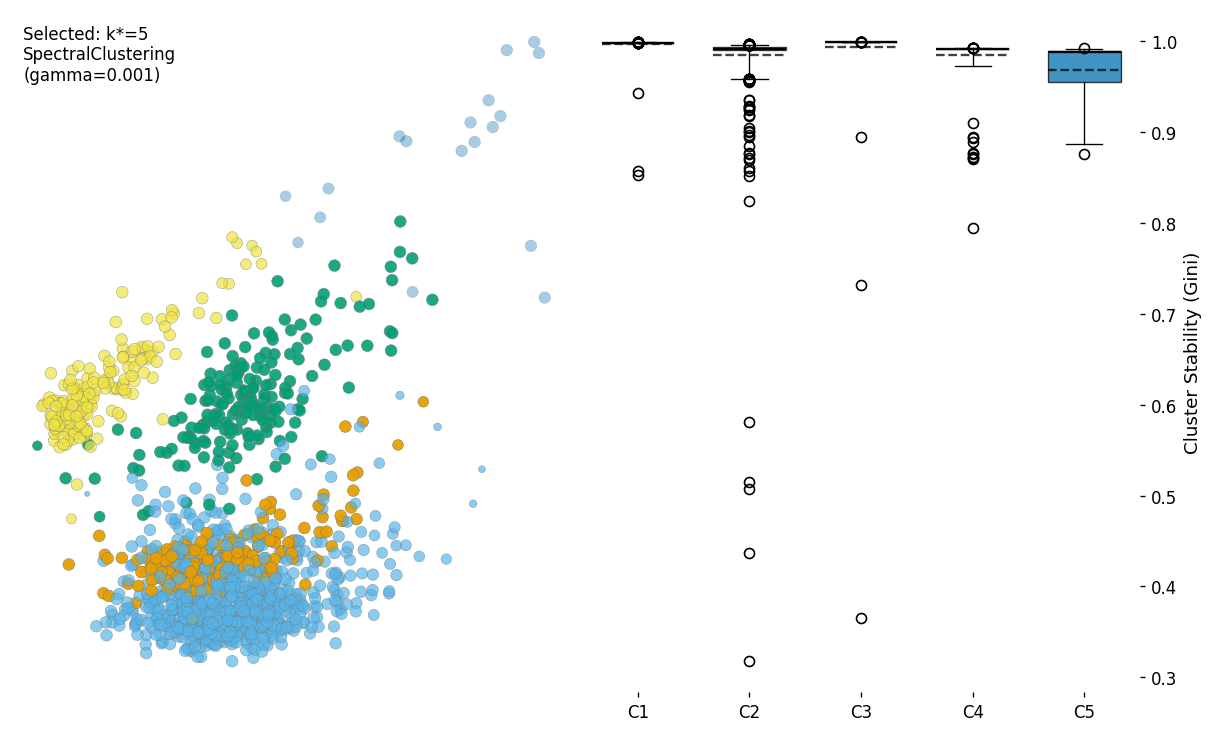

In [ ]:
carve.plot_clustering(measure='generalizability', rule='1se', interactive=False)

In [ ]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette 
silhouette_labels = SpectralClustering(n_clusters=2, gamma=gamma_005, random_state=RANDOM_SEED).fit_predict(X)

# Spectral, k=7 –– as suggested by CARVE generalizability 
carve_labels = carve.get_labels(k=4, measure="generalizability", rule="1se")

fig = alluvial_compare(
    y_true=y,
    left_labels=carve_labels,
    right_labels=silhouette_labels,
    left_title="CARVE",
    right_title="silhouette",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()


---

## 5) Motivational Plots:

In [ ]:
agg_labels = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X)

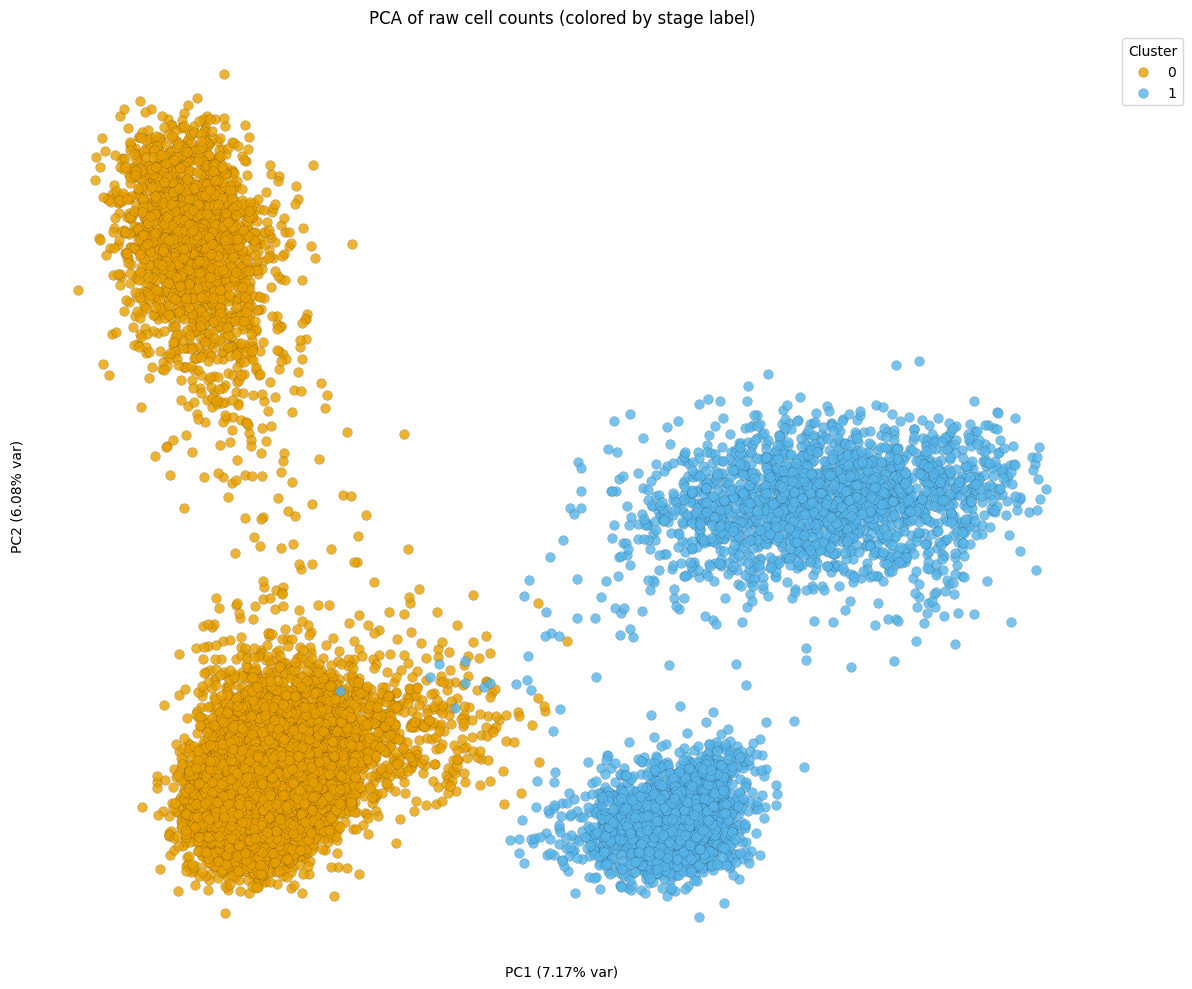

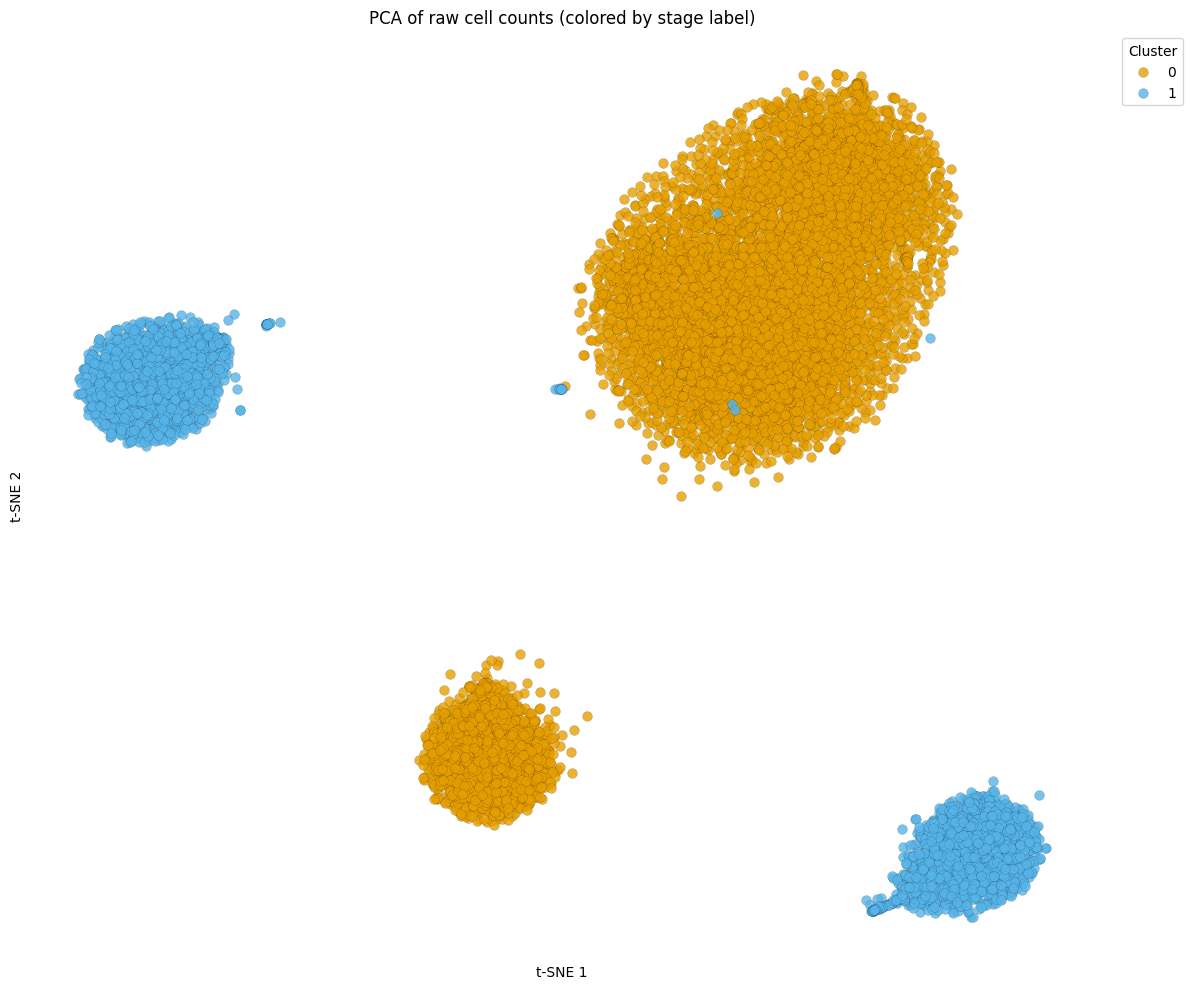

In [22]:
plot_dim_red(X=X, y=agg_labels, label_col="cell_type", legend_title='Cluster')

plot_dim_red(X=X, y=agg_labels, method='tsne', label_col="cell_type", legend_title='Cluster')

---